# Orecle Grading Results

Focused notebook for reviewing score distribution and answers that scored below 5.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

GRADES_CSV = Path("orecle_grades.csv")

pd.set_option("display.max_colwidth", 180)
plt.style.use("ggplot")

## Load Data

In [2]:
if not GRADES_CSV.exists():
    raise FileNotFoundError(f"Missing {GRADES_CSV}. Run orecle_grader.py first.")

grades = pd.read_csv(GRADES_CSV)
grades["score"] = pd.to_numeric(grades.get("score"), errors="coerce")
valid_scores = grades.dropna(subset=["score"]).copy()

print(f"Loaded {len(grades)} grade rows from {GRADES_CSV}")

Loaded 38 grade rows from orecle_grades.csv


## Score Summary

,metric,value
0,graded rows,38.000000
1,scored rows,38.000000
2,average score,4.552632
3,median score,5.000000
4,min score,2.000000
5,max score,5.000000
6,scores below 5,8.000000


,score,rows
2,2,3
1,3,3
3,4,2
0,5,30


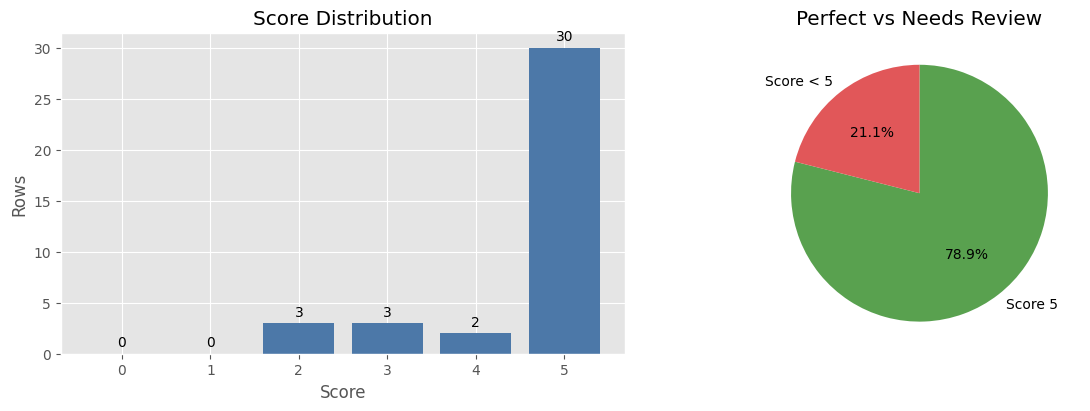

In [3]:
summary = pd.DataFrame([
    {"metric": "graded rows", "value": len(grades)},
    {"metric": "scored rows", "value": len(valid_scores)},
    {"metric": "average score", "value": grades["score"].mean()},
    {"metric": "median score", "value": grades["score"].median()},
    {"metric": "min score", "value": grades["score"].min()},
    {"metric": "max score", "value": grades["score"].max()},
    {"metric": "scores below 5", "value": (grades["score"] < 5).sum()},
])
display(summary)

score_counts = (
    grades["score"]
    .value_counts(dropna=False)
    .rename_axis("score")
    .reset_index(name="rows")
    .sort_values("score", na_position="last")
)
display(score_counts)

plot_counts = (
    valid_scores["score"]
    .astype(int)
    .value_counts()
    .reindex(range(0, 6), fill_value=0)
)
review_split = pd.Series({
    "Score 5": int((valid_scores["score"] == 5).sum()),
    "Score < 5": int((valid_scores["score"] < 5).sum()),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].bar(plot_counts.index, plot_counts.values, color="#4C78A8")
axes[0].set_title("Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Rows")
axes[0].set_xticks(range(0, 6))
axes[0].bar_label(axes[0].containers[0], padding=3)

axes[1].pie(
    review_split.values,
    labels=review_split.index,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
    colors=["#59A14F", "#E15759"],
    startangle=90,
    counterclock=False,
)
axes[1].set_title("Perfect vs Needs Review")

plt.show()

## Lowest Scoring Answers

In [4]:
review_cols = [col for col in ["slug", "title", "score", "feedback", "query", "answer"] if col in grades.columns]
lowest = grades.loc[grades["score"] < 5].sort_values(["score", "slug"], na_position="last")

if lowest.empty:
    print("No answers scored below 5.")
else:
    display(lowest[review_cols])

,slug,title,score,feedback,query,answer
2,buildingblocks_mp,Building Blocks,2,"The answer gives the correct vanilla recipe, but the retrieved context contains only item tags (listing chiseled stone bricks and stone brick slabs) and does not include or con...","In Building Blocks, how do I craft chiseled stone bricks?",Use two stone brick slabs stacked in the crafting grid.\n\nRecipe:\n- Place 1 stone brick slab in the middle top slot and 1 in the middle middle slot (a vertical column of two ...
9,minecraft-java-second-edition,Minecraft: Java Second Edition,2,"The provided recipe context contains no spyglass crafting information, so the answer (amethyst shard + 2 copper ingots) is not supported by the retrieved sources.","In Minecraft: Java Second Edition, how do I craft a spyglass?",You craft a spyglass on a crafting table using 1 amethyst shard and 2 copper ingots.\n\nRecipe (3x3 crafting table): place the amethyst shard above two copper ingots in a verti...
6,recorders-modpack,[Discontinued],2,The provided Clock recipe (4 gold + 1 redstone in a cross) is not supported by the retrieved context — none of the files include a Clock crafting recipe or mention the item.,"In [Discontinued], how do I craft a Clock?",Crafting recipe (vanilla Minecraft):\n\n- Ingredients: 4 Gold Ingots + 1 Redstone\n- Pattern in a 3×3 crafting grid:\n\n[ ] [Gold] [ ]\n[Gold] [Redstone] [Gold]\n[ ] [Gold] [ ]...
29,common-sense,Common-Sense,3,"Partially correct — the retrieved recipe files contain no saddle crafting recipe, but the Oracle’s additional details about loot, fishing, trading, and commands are not support...","In Common-Sense, how do I craft a saddle?","I checked the Common‑Sense recipe files available and there is no crafting recipe for a saddle. Like vanilla Minecraft, saddles in this modpack are not craftable.\n\nHow to get..."
1,diamond-age,Diamond Age,3,"Partially correct — the answer correctly observes the retrieved files are netherite smithing recipes and no bed.json is present, but the suggested old-bed crafting pattern is n...","In Diamond Age, how do I craft a bed (using the Old Bed Crafting Recipe datapack)?",I don't see the Old Bed recipe file in the files you pasted (those are old netherite smithing recipes). If you can paste the datapack recipe file (data/<namespace>/recipes/bed....
27,fabricly-light,Fabricly Light,3,"The assistant correctly notes the boombox recipe isn't present in the provided recipe files and offers useful ways to locate it, but it does not supply the actual crafting reci...","In Fabricly Light, how do I craft the Iam Music Player boombox?","I couldn't find the ""Iam Music Player boombox"" recipe in the recipe files you posted. The snippets you gave include other instrument/tech recipes but not that one.\n\nWays I ca..."
13,blockfront-mod-pack,BlockFront,4,"Correctly notes the provided files are tag lists and not a recipe (so the MG-42 recipe isn't present) and gives reasonable next-step methods to locate it, but it doesn't provid...","In BlockFront, how do I craft the MG-42?","I can't find an MG-42 crafting recipe in the snippet you gave — those files are tag lists (walls, fences, etc.), not recipe definitions. To find the MG-42 recipe in the BlockFr..."
28,jars-minecraft-plus,Minecraft Plus,4,The answer correctly lists the three crafting/smelting methods shown in the retrieved recipes (3 raw copper + 1 raw tin -> bronze_blend -> smelt to ingot; 3×3 nuggets -> ingot;...,"In Minecraft Plus, how do I craft a bronze ingot?",There are a few ways:\n\n1. Smelt a bronze blend\n- Craft 1 bronze_blend from 3 Raw Copper + 1 Raw Tin (shapeless).\n- Smelt the bronze_blend in a furnace/blast furnace to get ...
